# Projet : prédiction de peptide anti-microbien (AMP)

but du projet : intégrer un modèle qui caractérise les peptides antimicrobiens, notamment svm et Random Forest



In [45]:
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

## I- préparation des données :
### 1- Dataframe des données brutes:

#### - chargement et parsing AMP : 

In [2]:
fichiers_amp = {
    "human": "human_amp.fasta",
    "amphibian": "amphibian_amp.fasta",
    "animal":"animal_amp.fasta",
    "plant":"plant_amp.fasta",
    "insect":"insect_amp.fasta"
}
dfs=[]
for origine, fichier in fichiers_amp.items():
    records = list(SeqIO.parse(fichier, "fasta"))
    df = pd.DataFrame({
        "id": [r.id for r in records],
        "sequence" : [str(r.seq) for r in records],
        "label" : 1,
        "origine": origine 
    })
    dfs.append(df)

df_amp_global = pd.concat(dfs, ignore_index= True)


print(f"{len(df_amp_global)} sequences AMP globals chargées")


4513 sequences AMP globals chargées


#### - chargement et parsing non AMP:

In [3]:
records = list(SeqIO.parse("non_amp.fasta", "fasta"))
df_non_amp= pd.DataFrame({
    "id" : [r.id for r in records],
    "sequence" : [str(r.seq) for r in records],
    "label" : 0
})
print(f"{len(df_non_amp)} séquence non AMP chargées")

11195 séquence non AMP chargées


### 2- Conserver les peptide d'une longueur entre 15 et 60 A.A :

In [4]:
df_amp_global = df_amp_global[
    (df_amp_global["sequence"].str.len()>=15) &
    (df_amp_global["sequence"].str.len()<=60)
]

df_non_amp = df_non_amp[
    (df_non_amp["sequence"].str.len()>=15) &
    (df_non_amp["sequence"].str.len()<=60)
]
print(f"Après filtre longueur : {len(df_amp_global)}  peptides AMP global")
print(f"Après filtre longueur : {len(df_non_amp)}  peptides non AMP")



Après filtre longueur : 3606  peptides AMP global
Après filtre longueur : 11195  peptides non AMP


### 3- Vérifier que tous les acides aminées sont valides : 

In [5]:
df_amp_global = df_amp_global[
    df_amp_global["sequence"].str.match(r'^[ACDEFGHIKLMNPQRSTVWY]+$')
]

df_non_amp = df_non_amp[
    df_non_amp["sequence"].str.match(r'^[ACDEFGHIKLMNPQRSTVWY]+$')
]
print(f"Après filtre d'acides aminées valides : {len(df_amp_global)} peptides AMP global")
print(f"Après filtre d'acides aminées valides : {len(df_non_amp)} peptides non AMP")

Après filtre d'acides aminées valides : 3606 peptides AMP global
Après filtre d'acides aminées valides : 10886 peptides non AMP


### 4- suppression d'éventuels doublants :

In [6]:
df_amp_global = df_amp_global.drop_duplicates(subset="sequence")
df_non_amp = df_non_amp.drop_duplicates(subset="sequence")
print(f"Après suppression d'eventuels doublants : {len(df_amp_global)} peptides AMP global")
print(f"Après suppression d'eventuels doublants : {len(df_non_amp)} peptides non AMP")

Après suppression d'eventuels doublants : 2272 peptides AMP global
Après suppression d'eventuels doublants : 7520 peptides non AMP


### 5- Homogénéiser les tailles des datasets :

In [7]:
# Rééchantillonner les non-AMP par tranche de longueur
df_non_amp["longueur"] = df_non_amp["sequence"].str.len()
#df_amp_amph["longueur"] = df_amp_amph["sequence"].str.len()
df_amp_global["longueur"] = df_amp_global["sequence"].str.len()

tranches = [(15,25), (26,35), (36,45), (46,60)]
non_amp_homogene = []

for debut, fin in tranches:
    n_amp_tranche = len(df_amp_global[
        (df_amp_global["longueur"] >= debut) &
        (df_amp_global["longueur"] <= fin)
    ])
    
    non_amp_tranche = df_non_amp[
        (df_non_amp["longueur"] >= debut) &
        (df_non_amp["longueur"] <= fin)
    ]
#on prend le plus petit pour avoir la même taille de Dataset  
    n_dispo = len(non_amp_tranche)
    n_a_prendre = min(n_amp_tranche, n_dispo)
    
    non_amp_homogene.append(
        non_amp_tranche.sample(n=n_a_prendre, random_state=42)
    )
    print(f"Tranche {debut}-{fin} | AMP : {n_amp_tranche} | non-AMP prélevés : {n_a_prendre}")

df_non_amp_homogene = pd.concat(non_amp_homogene).reset_index(drop=True)

print(f"\nAMP            : {len(df_amp_global)}")
print(f"non-AMP homog. : {len(df_non_amp_homogene)}")
print(f"Longueur moy AMP     : {df_amp_global['sequence'].str.len().mean():.1f}")
print(f"Longueur moy non-AMP : {df_non_amp_homogene['sequence'].str.len().mean():.1f}")

Tranche 15-25 | AMP : 919 | non-AMP prélevés : 664
Tranche 26-35 | AMP : 669 | non-AMP prélevés : 669
Tranche 36-45 | AMP : 466 | non-AMP prélevés : 466
Tranche 46-60 | AMP : 218 | non-AMP prélevés : 218

AMP            : 2272
non-AMP homog. : 2017
Longueur moy AMP     : 30.4
Longueur moy non-AMP : 32.2


In [8]:
#homogéiniser les tailles amp non amp
n = min(len(df_amp_global), len(df_non_amp_homogene))

df_amp_final = df_amp_global.sample(n=n, random_state=42)
df_non_amp_final = df_non_amp_homogene.copy()

print(f"AMP final     : {len(df_amp_final)}")
print(f"non-AMP final : {len(df_non_amp_final)}")

AMP final     : 2017
non-AMP final : 2017


## II- Analyses exploratoire des données :

In [51]:
df_final = pd.concat([df_amp_final, df_non_amp_final], ignore_index=True)
df_final = df_final.sample(frac=1, random_state = 42).reset_index(drop=True)
df_final.to_csv("dataset.csv", header= True)
print(f"Dataset final : {len(df_final)} peptides")
print(df_final["label"].value_counts())


Dataset final : 4034 peptides
label
0    2017
1    2017
Name: count, dtype: int64


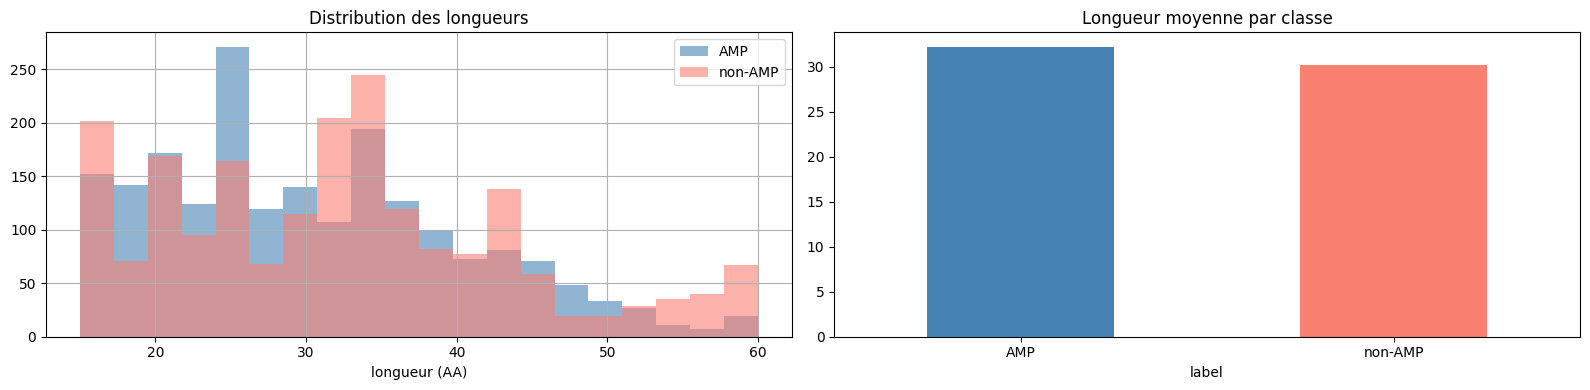

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df_final[df_final["label"]==1]["sequence"].str.len().hist(
    bins = 20, alpha=0.6, label="AMP", ax=axes[0], color="steelblue"
)
df_final[df_final["label"]==0]["sequence"].str.len().hist(
    bins = 20, alpha=0.6, label="non-AMP", ax=axes[0], color="salmon"
)
axes[0].set_title("Distribution des longueurs")
axes[0].set_xlabel("longueur (AA)")
axes[0].legend()

df_final.groupby("label")["sequence"].apply(
    lambda x: x.str.len().mean()
).plot.bar(ax=axes[1], color=["steelblue", "salmon"])
axes[1].set_title("Longueur moyenne par classe")
axes[1].set_xticklabels(["AMP", "non-AMP"], rotation=0)

plt.tight_layout()
plt.show()

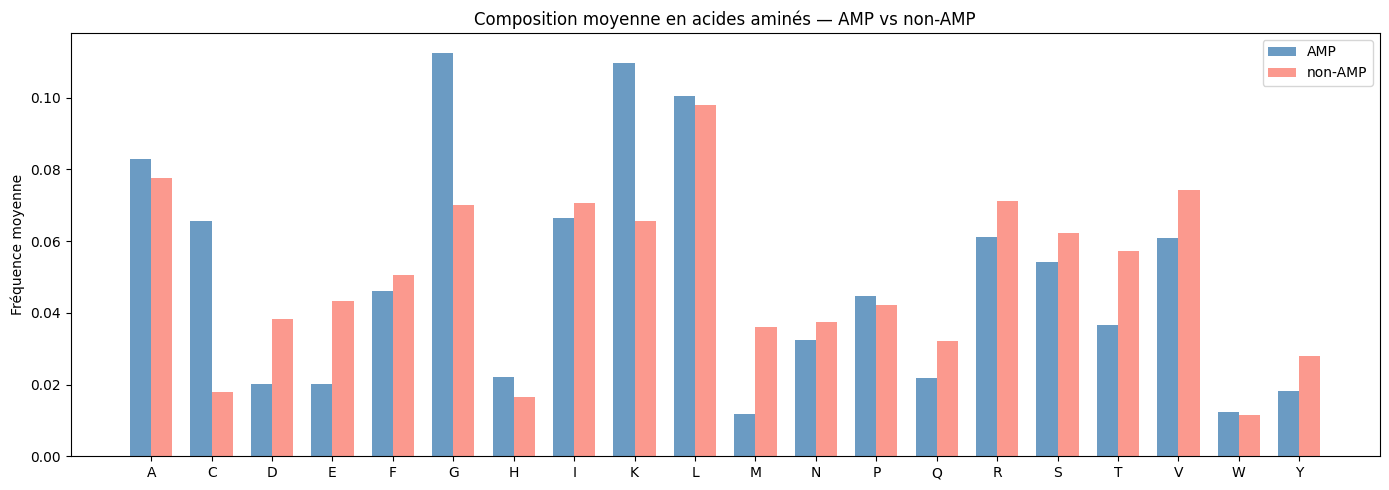

In [11]:

AA = list("ACDEFGHIKLMNPQRSTVWY")

def composition_moyenne(df):
    compo = {}
    for aa in AA:
        compo[aa] = df["sequence"].apply(
            lambda s: s.count(aa) / len(s)
        ).mean()
    return compo

compo_amp     = composition_moyenne(df_final[df_final["label"]==1])
compo_non_amp = composition_moyenne(df_final[df_final["label"]==0])

x = np.arange(len(AA))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, compo_amp.values(),     width, label="AMP",     color="steelblue", alpha=0.8)
ax.bar(x + width/2, compo_non_amp.values(), width, label="non-AMP", color="salmon",    alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(AA)
ax.set_title("Composition moyenne en acides aminés — AMP vs non-AMP")
ax.set_ylabel("Fréquence moyenne")
ax.legend()
plt.tight_layout()
plt.show()

## II- Modèle de prédiction:
### 1- Prépartion des données d'entré du modèle:

In [56]:
import sys

sys.path.append("../")

from models.peptide import Peptide
from config import AA_DATABASE
def build_feature_vector_v1(sequence):
    p= Peptide(sequence, "no_modif", "no_modif")
    #physico-chimique
    physico = [
        p.masse_molaire,
        p.charge_nette_ph_7,
        p.hydrophilie_moyenne,
        p.phi,
        p.longueur,
        p.coefficient_extinction
    ]
    composition = [
        sequence.count(aa) / len(sequence)
        for aa in sorted("ACDEFGHIKLMNPQRSTVWY")
    ]
    #composition N-ter et C-ter
    # 15 premiers AA
    n_term = sequence[:15].ljust(15, 'X')
    compo_nterm = [
        n_term.count(aa) / 15
        for aa in sorted("ACDEFGHIKLMNPQRSTVWY")
    ]
    
    # 15 derniers AA
    c_term = sequence[-15:].ljust(15, 'X')
    compo_cterm = [
        c_term.count(aa) / 15
        for aa in sorted("ACDEFGHIKLMNPQRSTVWY")
    ]

    return physico + composition + compo_nterm + compo_cterm
def build_feature_vector_v2(sequence):
    AA_ORDER = sorted("ACDEFGHIKLMNPQRSTVWY")
    p= Peptide(sequence, "no_modif", "no_modif")
    #physico-chimique
    physico = [
        p.masse_molaire,
        p.charge_nette_ph_7,
        p.hydrophilie_moyenne,
        p.phi,
        p.longueur,
        p.coefficient_extinction
    ]
    nterm_seq= sequence[:15].ljust(15, "-")
    binary_nterm=[]
    for a in nterm_seq:
        for aa in AA_ORDER:
            if a == aa:
                binary_nterm.append(1)
            else:
                binary_nterm.append(0)
        
    cterm_seq = sequence[-15:].ljust(15, "-")
    binary_cterm=[]
    for a in cterm_seq:
        for aa in AA_ORDER:
            if a == aa:
                binary_cterm.append(1)
            else:
                binary_cterm.append(0)

    return physico + binary_nterm + binary_cterm


## 2- Modèle SVM:

In [61]:
X =[]
y =[]
sequences_invalides = []
for _, row in df_final.iterrows():
    try:
        vecteur = build_feature_vector_v2(row["sequence"])
        X.append(vecteur)
        y.append(row["label"])
    except Exception as e:
        sequences_invalides.append(row["sequence"])
X = np.array(X)
y = np.array(y)
        
print(f"Features construites  : {len(X)} peptides")
print(f"Séquences ignorées    : {len(sequences_invalides)}")
print(f"Taille d'un vecteur   : {len(X[0])} features")

Features construites  : 4034 peptides
Séquences ignorées    : 0
Taille d'un vecteur   : 606 features


### séparer test et train:

In [65]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state= 42,
    stratify=y           # conserver l'équilibre AMP/non-AMP
)

print(f"Train : {len(X_train)} peptides")
print(f"Test  : {len(X_test)} peptides")

Train : 3227 peptides
Test  : 807 peptides


### Normalisation:

In [66]:
#met toutes les features à la même échelle
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Entraînement :

In [67]:
svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
print("Modèle entraîné !!")

Modèle entraîné !!


### Evaluation :

In [68]:
y_pred      = svm.predict(X_test_scaled)
y_pred_proba = svm.predict_proba(X_test_scaled)[:, 1]

# Rapport complet
print(classification_report(y_test, y_pred, target_names=["non-AMP", "AMP"]))

# AUC-ROC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC : {auc:.3f}")

              precision    recall  f1-score   support

     non-AMP       0.95      0.96      0.95       404
         AMP       0.96      0.95      0.95       403

    accuracy                           0.95       807
   macro avg       0.95      0.95      0.95       807
weighted avg       0.95      0.95      0.95       807

AUC-ROC : 0.991


### visualisation :

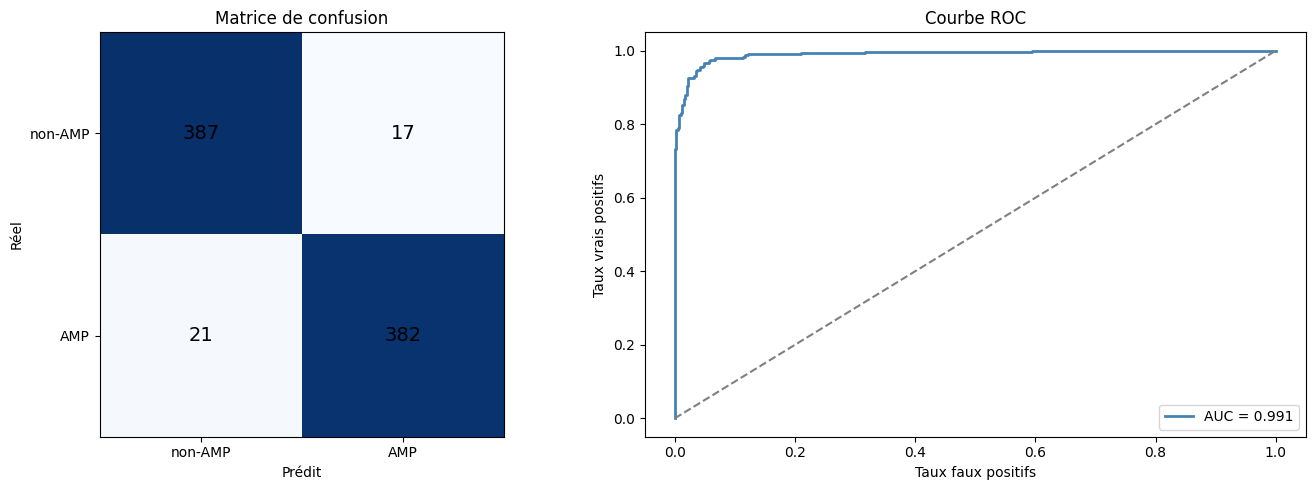

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["non-AMP", "AMP"])
axes[0].set_yticklabels(["non-AMP", "AMP"])
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title("Matrice de confusion")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[1].set_xlabel("Taux faux positifs")
axes[1].set_ylabel("Taux vrais positifs")
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

## vérification du modèle : 

### 1. Lancer la cross-validation 5-fold pour confirmer que ce n'est pas du surapprentissage :

In [70]:
scores_cv = cross_val_score(
    SVC(kernel="rbf", C=1.0, probability=True),
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring="accuracy"
)
print(f"Accuracy par fold : {scores_cv}")
print(f"Accuracy moyenne  : {scores_cv.mean():.3f} ± {scores_cv.std():.3f}")

Accuracy par fold : [0.95786865 0.95539033 0.94299876 0.95786865 0.93548387]
Accuracy moyenne  : 0.950 ± 0.009


### 2. vérifier la courbe d'apprentissage :

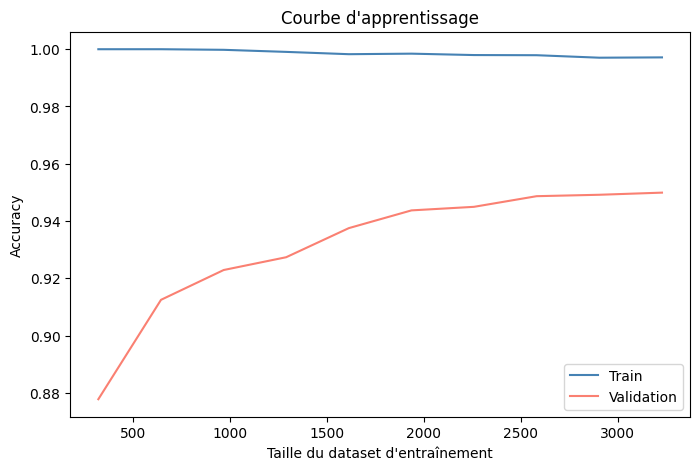

In [71]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel="rbf", C=1.0),
    scaler.fit_transform(X),
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train", color="steelblue")
plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation", color="salmon")
plt.xlabel("Taille du dataset d'entraînement")
plt.ylabel("Accuracy")
plt.title("Courbe d'apprentissage")
plt.legend()
plt.show()

In [73]:
import joblib
joblib.dump(svm,    "../data/model.pkl")
joblib.dump(scaler, "../data/scaler.pkl")
print("Modèle et scaler sauvegardés !")

Modèle et scaler sauvegardés !
